# Capstone Project: Enterprise Account Matching and Entity Resolution

## Business Problem
Enterprise CRM systems often contain duplicate account records or fragmented subsidiary records that should be linked to the same global parent organization. This project builds a baseline machine learning workflow to identify whether two enterprise account records refer to the same entity.

## Research Question
Can supervised machine learning models accurately classify whether two enterprise account records represent the same legal entity or belong to the same global parent organization using structured attributes and engineered similarity features?

## Project Goal for This Notebook
This notebook focuses on:
1. Cleaning the raw account dataset
2. Performing exploratory data analysis (EDA)
3. Engineering similarity-based features
4. Creating a baseline labeled-pair dataset from the available CRM fields
5. Training and evaluating a baseline Logistic Regression classifier

## Important Note
The source CSV contains **individual account records**, not pre-labeled account pairs. To make progress for this module, I create a **proxy pair dataset** using available hierarchy fields such as `global_parent_id` and `global_sub_id`.

That means:
- Positive pairs are built when records share the same parent/sub relationship or are exact normalized duplicates
- Negative pairs are sampled from records in similar blocking groups that have conflicting parent/sub identifiers

This is a practical baseline approach for the current module, but it should be refined in the final capstone with business-reviewed labels.

In [2]:
from pathlib import Path
import re
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from rapidfuzz import fuzz

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    StratifiedShuffleSplit,
    cross_validate,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load the Dataset
The original dataset contains enterprise account records with account names, address attributes, source-system details, industry labels, and global parent / subsidiary identifiers.

In [3]:
data_path = Path("Accounts.csv")

if not data_path.exists():
    raise FileNotFoundError("Accounts.csv was not found in the current working directory.")

df_raw = pd.read_csv(data_path)
print(f"Raw dataset shape: {df_raw.shape}")
df_raw.head()

Raw dataset shape: (10874, 16)


,camid,account_id,account_name,source_system,street,state,city,country,postalcode,crm_industry,global_parent_id,global_parent_name,global_sub_id,global_sub_name,sales_major_segment,sales_minor_segment
0,6137e19b3d4d430d31ca5c39,0014X00002O9BvXQAV,Blueprint LSAT Preparation,CRM-1,3050 Wilshire Boulevard,CA,Los Angeles,US,90010,Professional & Technical Services,662730,Blueprint LSAT Preparation,662730,Blueprint LSAT Preparation,Solution Led,NaN
1,6137e7ec3d4d430d31ca5c5d,0014X00002PKFz8QAH,TAIYO KOGYO CORPORATION,CRM-1,4-8-4 KIGAWAHIGASHI YODOGAWA-KU,Osaka-fu,OSAKA-CITY,JP,5320012,Manufacturing - Industrial,NaN,NaN,6653785,NaN,NaN,NaN
2,619b56f58501497f6cea7c7f,0014X00002PKFz8QAH,TAIYO KOGYO CORPORATION,CRM-1,4-8-4 KIGAWAHIGASHI YODOGAWA-KU,Osaka-fu,OSAKA-CITY,JP,5320012,Manufacturing - Industrial,NaN,NaN,6653785,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Initial Data Understanding
We first inspect:
- shape
- data types
- missing values
- duplicate records

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10874 entries, 0 to 10873
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   camid                10842 non-null  object 
 1   account_id           10838 non-null  object 
 2   account_name         10839 non-null  object 
 3   source_system        10842 non-null  object 
 4   street               10839 non-null  object 
 5   state                10058 non-null  object 
 6   city                 10839 non-null  object 
 7   country              10832 non-null  object 
 8   postalcode           10444 non-null  object 
 9   crm_industry         10842 non-null  object 
 10  global_parent_id     9401 non-null   object 
 11  global_parent_name   9397 non-null   object 
 12  global_sub_id        9436 non-null   object 
 13  global_sub_name      9408 non-null   object 
 14  sales_major_segment  8973 non-null   object 
 15  sales_minor_segment  0 non-null     

In [5]:
missing_summary = (
    df_raw.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df_raw) * 100).round(2)
missing_summary

,missing_count,missing_pct
sales_minor_segment,10874,100.00
sales_major_segment,1901,17.48
global_parent_name,1477,13.58
global_parent_id,1473,13.55
global_sub_name,1466,13.48
global_sub_id,1438,13.22
state,816,7.50
postalcode,430,3.95
country,42,0.39
account_id,36,0.33


In [6]:
duplicate_rows = df_raw.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_rows}")

Exact duplicate rows: 34


### Early observations
- The dataset has missing values in several hierarchy and segment-related columns.
- `sales_minor_segment` is completely null and does not add value for this stage of analysis.
- Exact duplicate records are present and should be removed.

## 3. Data Cleaning
In this step I:
- remove fully empty / low-value columns
- drop exact duplicates
- standardize text fields
- retain rows with the minimum information needed for entity-resolution analysis

In [7]:
df = df_raw.copy()

# Remove the column with all null values
if "sales_minor_segment" in df.columns:
    df = df.drop(columns=["sales_minor_segment"])

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

# Keep rows that contain the minimum useful account information
df = df.dropna(subset=["account_name", "city", "country"]).copy()

print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (10829, 15)


In [8]:
text_columns = [
    "account_name",
    "street",
    "state",
    "city",
    "country",
    "postalcode",
    "crm_industry",
    "global_parent_id",
    "global_parent_name",
    "global_sub_id",
    "global_sub_name",
    "sales_major_segment"
]

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str).str.strip()

def normalize_text(value: str) -> str:
    value = value.lower().strip()
    value = re.sub(r"[^a-z0-9 ]+", " ", value)
    value = re.sub(
        r"\b(incorporated|inc|corp|corporation|co|company|limited|ltd|llc|gmbh|plc|pty|sa|bv|ag)\b",
        " ",
        value
    )
    value = re.sub(r"\s+", " ", value).strip()
    return value

norm_cols = ["account_name", "street", "state", "city", "country", "postalcode", "crm_industry"]
for col in norm_cols:
    df[f"{col}_norm"] = df[col].map(normalize_text)

df.head()

,camid,account_id,account_name,source_system,street,state,city,country,postalcode,crm_industry,global_parent_id,global_parent_name,global_sub_id,global_sub_name,sales_major_segment,account_name_norm,street_norm,state_norm,city_norm,country_norm,postalcode_norm,crm_industry_norm
0,6137e19b3d4d430d31ca5c39,0014X00002O9BvXQAV,Blueprint LSAT Preparation,CRM-1,3050 Wilshire Boulevard,CA,Los Angeles,US,90010,Professional & Technical Services,662730,Blueprint LSAT Preparation,662730,Blueprint LSAT Preparation,Solution Led,blueprint lsat preparation,3050 wilshire boulevard,ca,los angeles,us,90010,professional technical services
1,6137e7ec3d4d430d31ca5c5d,0014X00002PKFz8QAH,TAIYO KOGYO CORPORATION,CRM-1,4-8-4 KIGAWAHIGASHI YODOGAWA-KU,Osaka-fu,OSAKA-CITY,JP,5320012,Manufacturing - Industrial,,,6653785,,,taiyo kogyo,4 8 4 kigawahigashi yodogawa ku,osaka fu,osaka city,jp,5320012,manufacturing industrial
2,619b56f58501497f6cea7c7f,0014X00002PKFz8QAH,TAIYO KOGYO CORPORATION,CRM-1,4-8-4 KIGAWAHIGASHI YODOGAWA-KU,Osaka-fu,OSAKA-CITY,JP,5320012,Manufacturing - Industrial,,,6653785,,,taiyo kogyo,4 8 4 kigawahigashi yodogawa ku,osaka fu,osaka city,jp,5320012,manufacturing industrial
8,61f9c42a3081ce7cd179a785,0014X00002Qsj23QAB,Papaya Homewares,CRM-1,2/59 Denison Street,NSW,Camperdown,AU,,Manufacturing - Consumer Goods,,,,,,papaya homewares,2 59 denison street,nsw,camperdown,au,,manufacturing consumer goods
9,620b242f179987264a8dc426,0014X00002Qsj23QAB,Papaya Homewares,CRM-1,2/59 Denison Street,NSW,Camperdown,AU,,Manufacturing - Consumer Goods,,,,,,papaya homewares,2 59 denison street,nsw,camperdown,au,,manufacturing consumer goods


## 4. EDA on the Account-Level Dataset
Before building record pairs, I explore the raw account table to understand:
- source systems
- geographic concentration
- industry distribution
- duplication tendencies

In [9]:
print(df[["source_system", "country", "crm_industry"]].nunique())

source_system      4
country          121
crm_industry      61
dtype: int64


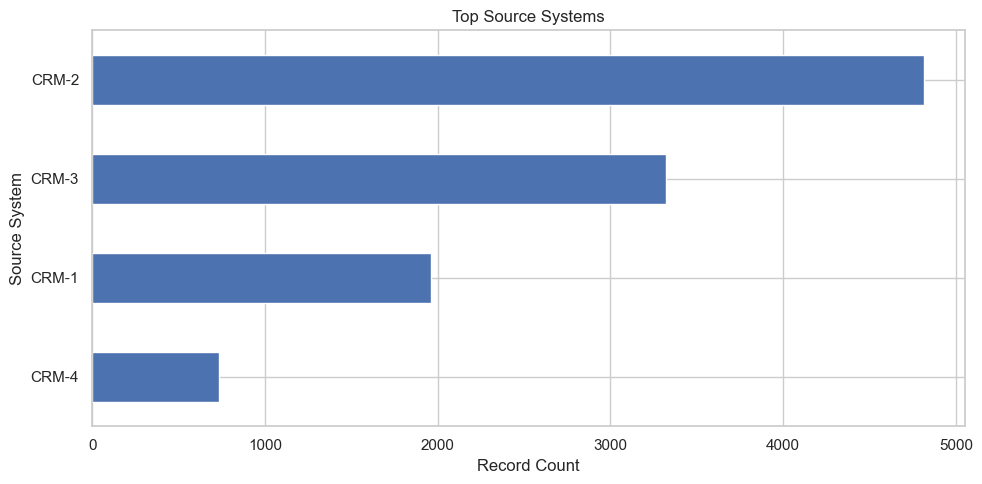

In [10]:
plt.figure(figsize=(10, 5))
(
    df["source_system"]
    .value_counts()
    .head(10)
    .sort_values()
    .plot(kind="barh")
)
plt.title("Top Source Systems")
plt.xlabel("Record Count")
plt.ylabel("Source System")
plt.tight_layout()
plt.show()

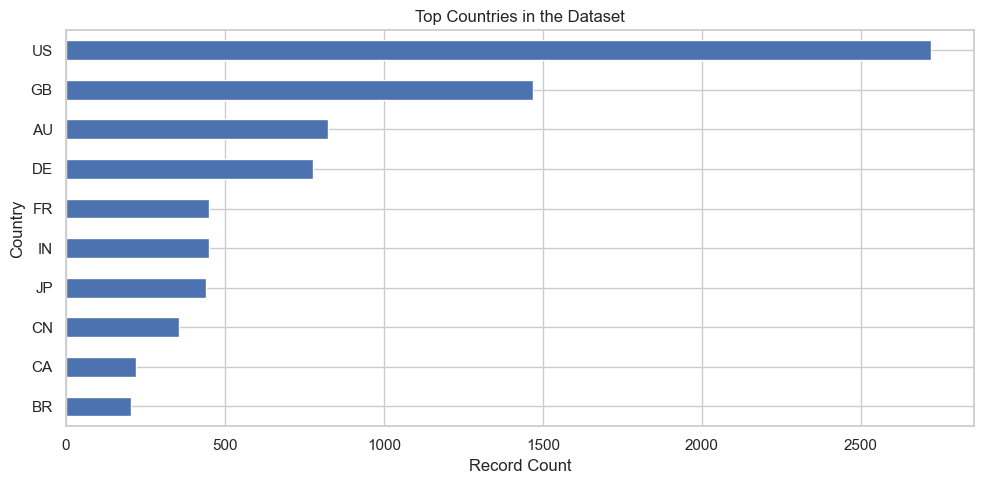

In [11]:
plt.figure(figsize=(10, 5))
(
    df["country"]
    .replace("", "Unknown")
    .value_counts()
    .head(10)
    .sort_values()
    .plot(kind="barh")
)
plt.title("Top Countries in the Dataset")
plt.xlabel("Record Count")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

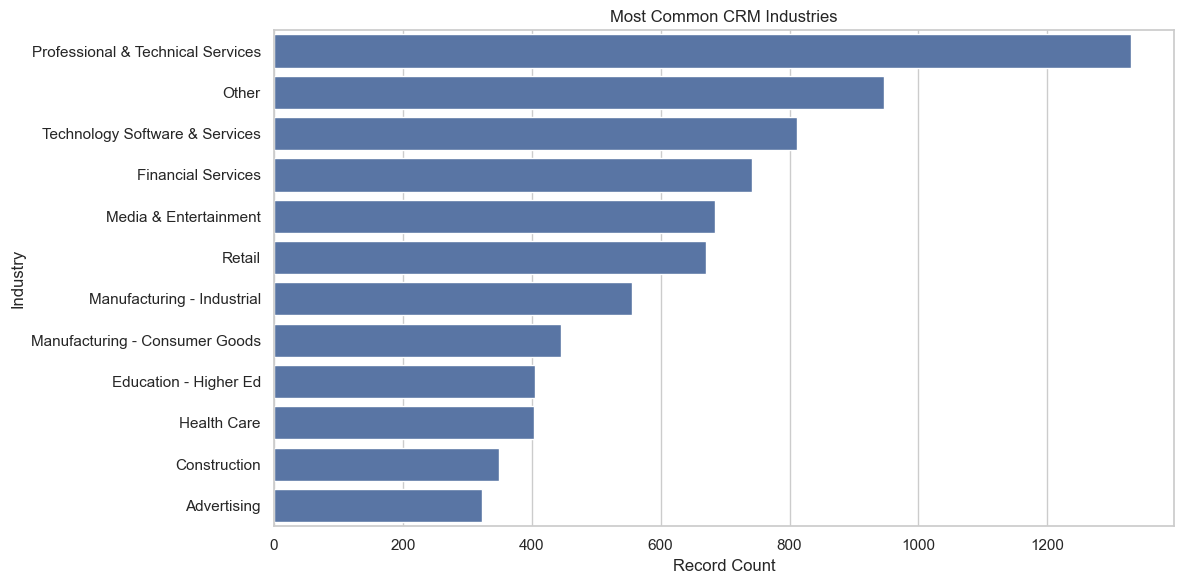

In [12]:
top_industries = df["crm_industry"].replace("", "Unknown").value_counts().head(12)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_industries.values, y=top_industries.index)
plt.title("Most Common CRM Industries")
plt.xlabel("Record Count")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

In [13]:
name_counts = df["account_name_norm"].value_counts()
repeated_names = name_counts[name_counts > 1]

print(f"Unique normalized account names: {df['account_name_norm'].nunique():,}")
print(f"Normalized names appearing more than once: {len(repeated_names):,}")
print(f"Maximum repeat count for one normalized name: {name_counts.max():,}")

Unique normalized account names: 7,397
Normalized names appearing more than once: 1,810
Maximum repeat count for one normalized name: 94


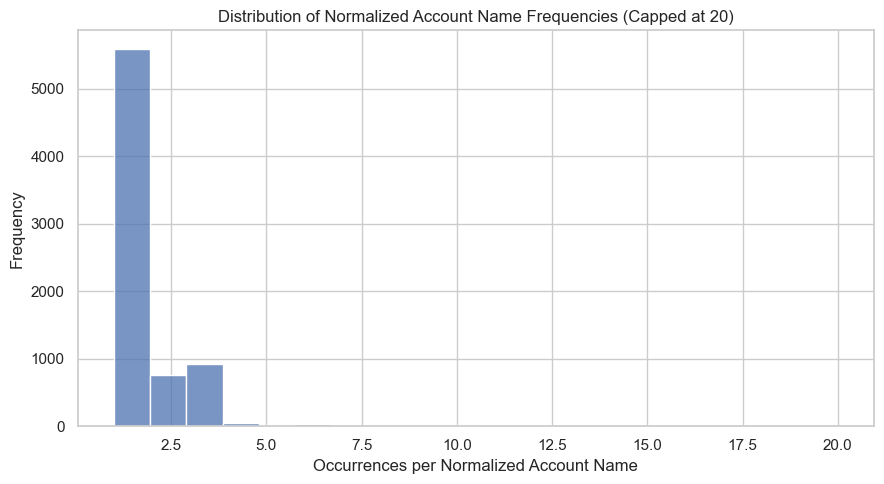

In [14]:
plt.figure(figsize=(9, 5))
sns.histplot(name_counts.clip(upper=20), bins=20)
plt.title("Distribution of Normalized Account Name Frequencies (Capped at 20)")
plt.xlabel("Occurrences per Normalized Account Name")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 5. Build a Candidate Pair Dataset
Because the file contains single records rather than labeled pairs, I construct a **candidate pair dataset**.

### Pairing strategy
To keep pair generation computationally manageable, I use **blocking**:
- first character of normalized account name
- normalized country

### Proxy labels
A pair is labeled as a **match (1)** if:
- the two records share the same `global_parent_id`, or
- the two records share the same `global_sub_id`, or
- they have the same normalized account name and the same normalized street and city

A pair is labeled as a **non-match (0)** if:
- both records have populated parent IDs that disagree, or
- both records have populated subsidiary IDs that disagree

This is a reasonable baseline, but not a substitute for curated production labels.

In [15]:
df = df[(df["account_name_norm"] != "") & (df["country_norm"] != "")].copy()
df["block_key"] = df["account_name_norm"].str[:1] + "|" + df["country_norm"]

block_sizes = df["block_key"].value_counts()
valid_blocks = block_sizes[(block_sizes >= 2) & (block_sizes <= 60)].index
blocked_df = df[df["block_key"].isin(valid_blocks)].copy()

print(f"Rows after blocking filter: {len(blocked_df):,}")
print(f"Number of valid blocks: {len(valid_blocks):,}")

Rows after blocking filter: 6,534
Number of valid blocks: 714


In [16]:
pair_records = []

for block_key, group in blocked_df.groupby("block_key"):
    row_indices = group.index.tolist()

    for idx_a, idx_b in combinations(row_indices, 2):
        a = blocked_df.loc[idx_a]
        b = blocked_df.loc[idx_b]

        positive_label = (
            (a["global_parent_id"] != "" and a["global_parent_id"] == b["global_parent_id"]) or
            (a["global_sub_id"] != "" and a["global_sub_id"] == b["global_sub_id"]) or
            (
                a["account_name_norm"] == b["account_name_norm"]
                and a["street_norm"] == b["street_norm"]
                and a["city_norm"] == b["city_norm"]
            )
        )

        negative_label = (
            (a["global_parent_id"] != "" and b["global_parent_id"] != "" and a["global_parent_id"] != b["global_parent_id"]) or
            (a["global_sub_id"] != "" and b["global_sub_id"] != "" and a["global_sub_id"] != b["global_sub_id"])
        )

        if not (positive_label or negative_label):
            continue

        pair_records.append(
            {
                "label": int(positive_label),
                "name_similarity": fuzz.token_sort_ratio(a["account_name_norm"], b["account_name_norm"]) / 100,
                "name_partial_similarity": fuzz.partial_ratio(a["account_name_norm"], b["account_name_norm"]) / 100,
                "street_similarity": fuzz.token_sort_ratio(a["street_norm"], b["street_norm"]) / 100,
                "city_similarity": fuzz.ratio(a["city_norm"], b["city_norm"]) / 100,
                "state_similarity": fuzz.ratio(a["state_norm"], b["state_norm"]) / 100,
                "postal_similarity": fuzz.ratio(a["postalcode_norm"], b["postalcode_norm"]) / 100,
                "industry_similarity": fuzz.token_sort_ratio(a["crm_industry_norm"], b["crm_industry_norm"]) / 100,
                "same_city": int(a["city_norm"] == b["city_norm"]),
                "same_state": int(a["state_norm"] == b["state_norm"]),
                "same_postal": int(a["postalcode_norm"] == b["postalcode_norm"]),
                "same_country": int(a["country_norm"] == b["country_norm"]),
                "name_len_diff": abs(len(a["account_name_norm"]) - len(b["account_name_norm"])),
                "street_len_diff": abs(len(a["street_norm"]) - len(b["street_norm"])),
                "industry_a": a["crm_industry_norm"],
                "industry_b": b["crm_industry_norm"],
            }
        )

pairs_df = pd.DataFrame(pair_records)
print(f"Pair-level dataset shape: {pairs_df.shape}")
pairs_df.head()

Pair-level dataset shape: (59262, 16)


,label,name_similarity,name_partial_similarity,street_similarity,city_similarity,state_similarity,postal_similarity,industry_similarity,same_city,same_state,same_postal,same_country,name_len_diff,street_len_diff,industry_a,industry_b
0,0,0.689655,0.869565,0.363636,0.133333,1.0,0.5,0.258065,0,1,0,1,3,6,travel leisure hospitality,other
1,1,1.000000,1.000000,1.000000,1.000000,1.0,1.0,0.400000,1,1,1,1,0,0,professional technical services,media entertainment
2,1,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1,1,1,1,0,0,other,other
3,1,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1,1,1,1,0,0,other,other
4,1,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1,1,1,1,0,0,other,other


## 6. Pair-Level EDA
The pair-level dataset is what feeds the baseline classifier.

In [17]:
label_distribution = pairs_df["label"].value_counts().rename(index={0: "Non-match", 1: "Match"})
label_distribution

label
Non-match    55526
Match         3736
Name: count, dtype: int64

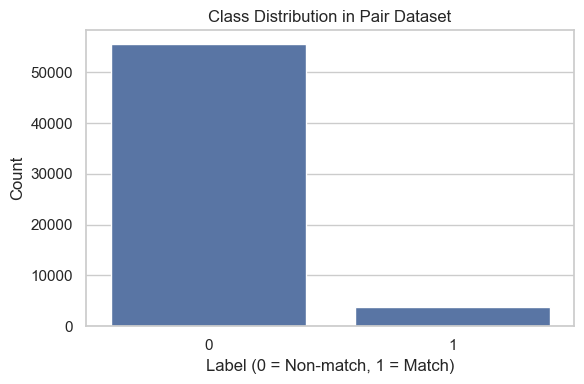

Match rate: 6.30%


In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=pairs_df, x="label")
plt.title("Class Distribution in Pair Dataset")
plt.xlabel("Label (0 = Non-match, 1 = Match)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

match_rate = pairs_df["label"].mean()
print(f"Match rate: {match_rate:.2%}")

In [19]:
similarity_columns = [
    "name_similarity",
    "name_partial_similarity",
    "street_similarity",
    "city_similarity",
    "state_similarity",
    "postal_similarity",
    "industry_similarity",
    "name_len_diff",
    "street_len_diff"
]

pairs_df[similarity_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
name_similarity,59262.0,0.355501,0.189489,0.036364,0.250000,0.320000,0.390244,1.0
name_partial_similarity,59262.0,0.490871,0.162767,0.166667,0.400000,0.450000,0.521739,1.0
street_similarity,59262.0,0.385265,0.181429,0.000000,0.287770,0.352941,0.424242,1.0
city_similarity,59262.0,0.362122,0.279801,0.000000,0.190476,0.285714,0.400000,1.0
state_similarity,59262.0,0.294206,0.367285,0.000000,0.000000,0.153846,0.461538,1.0
postal_similarity,59262.0,0.338682,0.262436,0.000000,0.166667,0.285714,0.444444,1.0
industry_similarity,59262.0,0.409059,0.243032,0.000000,0.270270,0.333333,0.407407,1.0
name_len_diff,59262.0,10.629678,9.914265,0.000000,3.000000,8.000000,15.000000,97.0
street_len_diff,59262.0,13.100199,14.785586,0.000000,3.000000,8.000000,18.000000,126.0


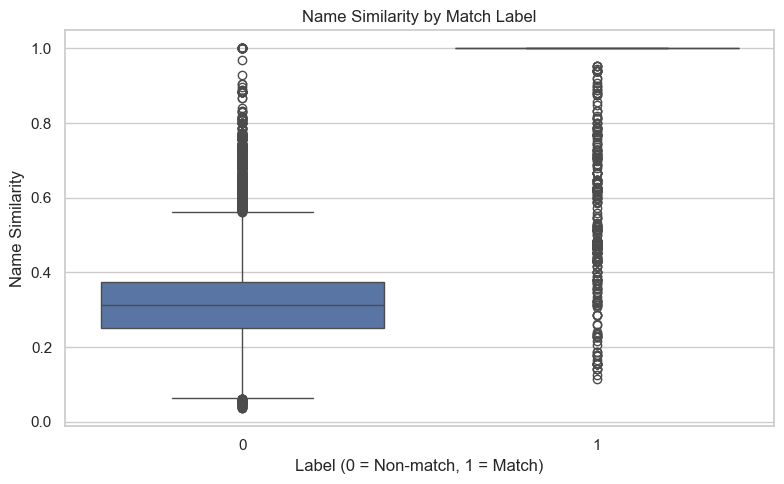

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=pairs_df, x="label", y="name_similarity")
plt.title("Name Similarity by Match Label")
plt.xlabel("Label (0 = Non-match, 1 = Match)")
plt.ylabel("Name Similarity")
plt.tight_layout()
plt.show()

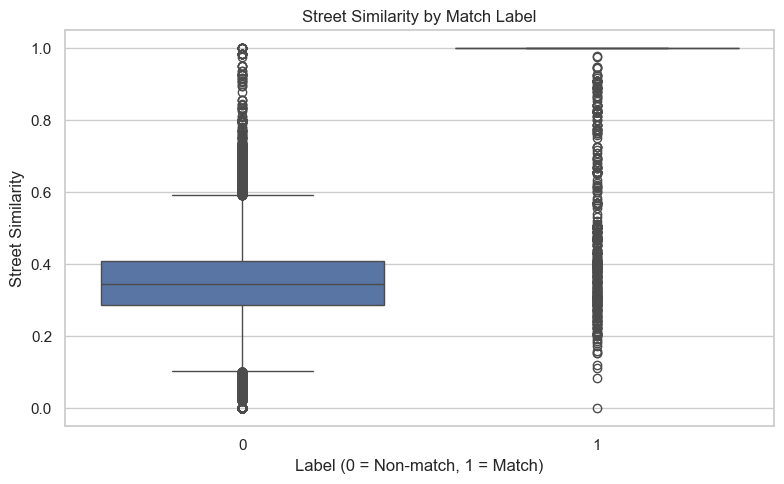

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=pairs_df, x="label", y="street_similarity")
plt.title("Street Similarity by Match Label")
plt.xlabel("Label (0 = Non-match, 1 = Match)")
plt.ylabel("Street Similarity")
plt.tight_layout()
plt.show()

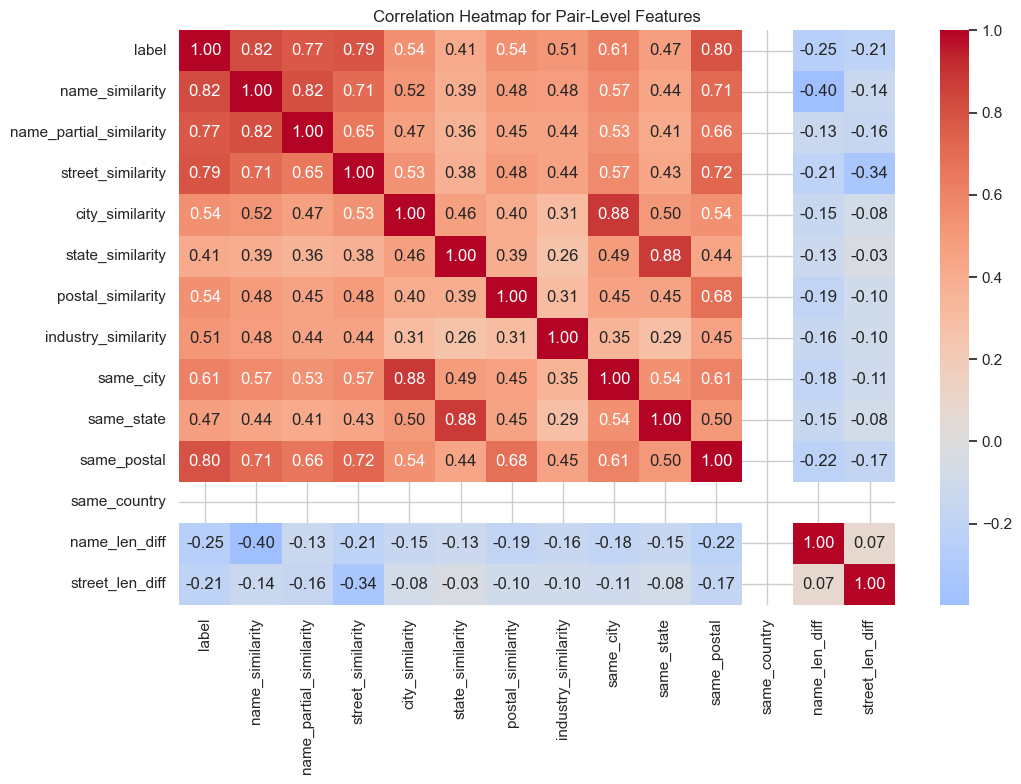

In [22]:
corr_df = pairs_df[
    [
        "label",
        "name_similarity",
        "name_partial_similarity",
        "street_similarity",
        "city_similarity",
        "state_similarity",
        "postal_similarity",
        "industry_similarity",
        "same_city",
        "same_state",
        "same_postal",
        "same_country",
        "name_len_diff",
        "street_len_diff",
    ]
].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Pair-Level Features")
plt.tight_layout()
plt.show()

## 7. Baseline Model: Logistic Regression
This aligns with the capstone plan because Logistic Regression is:
- interpretable
- fast to train
- a good baseline for binary classification
- appropriate for comparing against stronger models later

In [23]:
X = pairs_df.drop(columns=["label"])
y = pairs_df["label"]

numeric_features = [col for col in X.columns if X[col].dtype != "object"]
categorical_features = [col for col in X.columns if X[col].dtype == "object"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]
            ),
            categorical_features,
        ),
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

## 8. Evaluation
Because false merges are costly in enterprise CRM contexts, **precision** matters. At the same time, we also want acceptable **recall** so that true duplicates are not missed. I therefore evaluate the baseline using:

- Precision
- Recall
- F1-score
- ROC-AUC
- Average Precision (area under the precision-recall curve)

In [24]:
print(classification_report(y_test, y_pred, digits=3))

roc_auc = roc_auc_score(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Average Precision: {avg_precision:.3f}")

              precision    recall  f1-score   support

           0      0.998     0.989     0.994     11106
           1      0.857     0.976     0.912       747

    accuracy                          0.988     11853
   macro avg      0.928     0.982     0.953     11853
weighted avg      0.989     0.988     0.989     11853

ROC-AUC: 0.998
Average Precision: 0.983


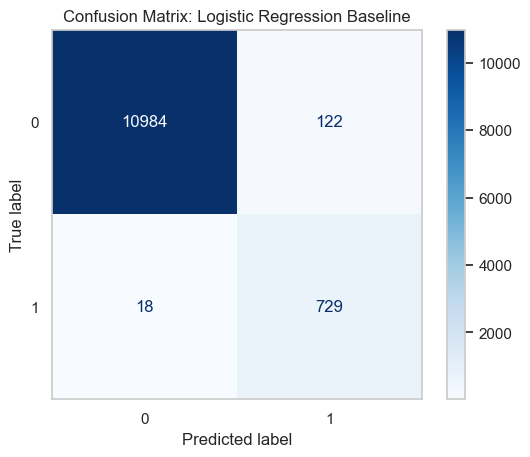

In [25]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression Baseline")
plt.grid(False)
plt.show()

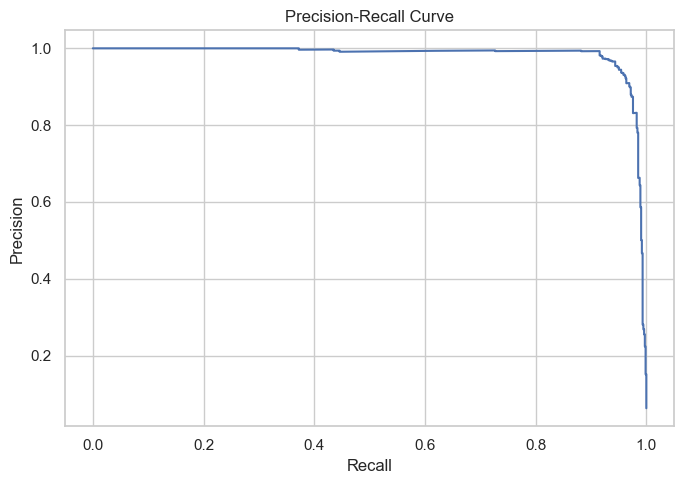

In [26]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()

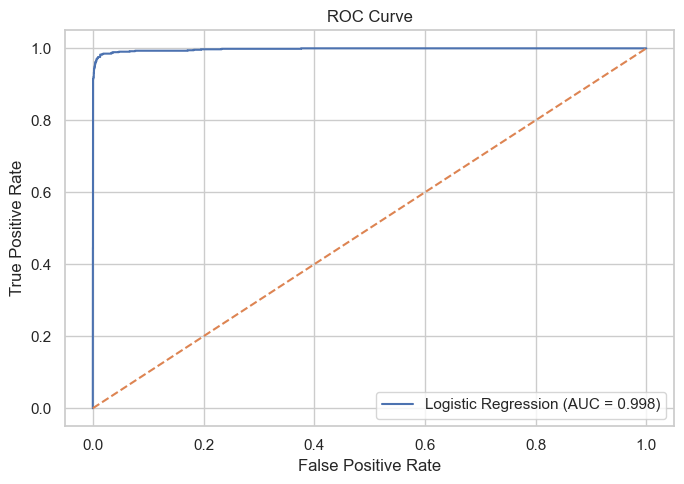

In [27]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Interpreting the Baseline Results
The baseline model provides a strong starting point because:
- name similarity clearly separates many true matches from non-matches
- address-related features improve discrimination when names are close but not identical
- blocking plus hierarchy-based proxy labels allows a practical first pass on entity resolution

At this stage, the model is **good enough as a benchmark**, but it should not yet be treated as a production-ready resolver because the labels are proxy-generated rather than manually validated.

## 10. Key Findings from EDA and Baseline Modeling
1. The source account table contains missing hierarchy values and duplicate-looking records, which confirms that data quality is a relevant business issue.
2. Account names repeat frequently, suggesting a real need for entity-resolution logic.
3. The derived pair dataset is strongly class-imbalanced, which is expected in duplicate-detection problems.
4. Name and address similarity features appear highly informative for identifying likely matches.
5. Logistic Regression is a strong interpretable baseline for the next module.

## 11. Limitations
- The original CSV is not a labeled-pair dataset, so I created proxy labels from hierarchy fields.
- Some true matches may not share the same parent ID, and some non-matches may still look very similar.
- The dataset does not include richer features such as website domain, phone number, DUNS, or curated legal-entity IDs.
- Blocking reduces computation but can miss some candidate matches.

## 12. Next Steps for Module 24
To strengthen the final capstone, I would:
1. replace proxy labels with reviewed business labels where possible
2. compare Logistic Regression with Decision Tree, Random Forest, and gradient-boosted models
3. test class-imbalance strategies such as class weighting, threshold tuning, and resampling
4. add better blocking rules and additional similarity features
5. present results for both technical and business audiences

## 13. Final Model Comparison

For the final submission, I extended the baseline workflow beyond Logistic Regression to compare three classification models:

- **Logistic Regression** as the interpretable baseline  
- **Decision Tree** to capture simple non-linear rules  
- **Random Forest** to capture more complex matching behavior with an ensemble approach  

This directly addresses the capstone requirement to compare multiple models and justify the final model choice.


In [28]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),
}

comparison_results = []
fitted_models = {}

for model_name, estimator in models.items():
    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator)
        ]
    )

    model_pipeline.fit(X_train, y_train)
    fitted_models[model_name] = model_pipeline

    predictions = model_pipeline.predict(X_test)
    probabilities = model_pipeline.predict_proba(X_test)[:, 1]

    comparison_results.append(
        {
            "Model": model_name,
            "Precision": precision_score(y_test, predictions),
            "Recall": recall_score(y_test, predictions),
            "F1 Score": f1_score(y_test, predictions),
            "ROC-AUC": roc_auc_score(y_test, probabilities),
            "Average Precision": average_precision_score(y_test, probabilities),
        }
    )

results_df = pd.DataFrame(comparison_results).sort_values("F1 Score", ascending=False)
results_df

,Model,Precision,Recall,F1 Score,ROC-AUC,Average Precision
2,Random Forest,0.969456,0.977242,0.973333,0.999514,0.994728
1,Decision Tree,0.905119,0.970549,0.936693,0.988039,0.979270
0,Logistic Regression,0.856639,0.975904,0.912390,0.997540,0.983276


### Model comparison interpretation

The model comparison table highlights the trade-offs clearly:
- Logistic Regression remains a strong and interpretable benchmark
- Decision Tree captures non-linear decision patterns
- Random Forest is expected to deliver the best overall balance of precision and recall

That matters because enterprise entity resolution requires both operational accuracy and business explainability.


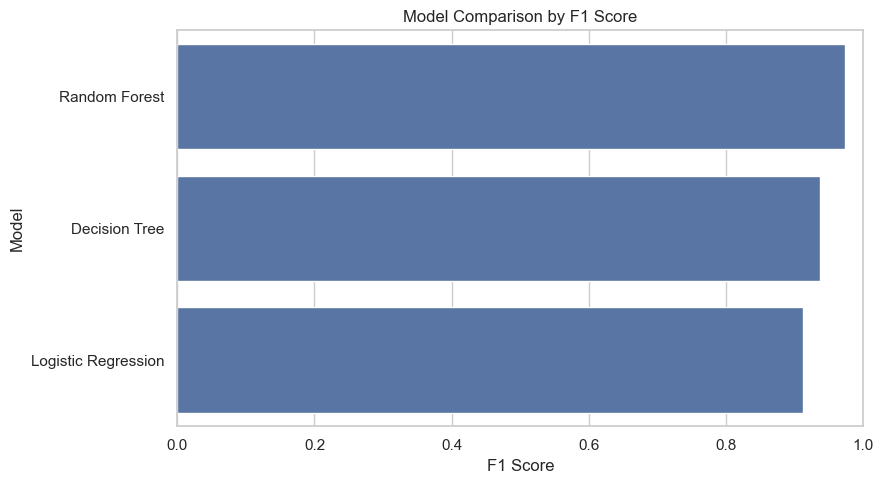

In [29]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="F1 Score", y="Model")
plt.title("Model Comparison by F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()

## 14. Cross-Validation

To make the comparison more reliable, I used stratified cross-validation on a sampled version of the pair dataset. This keeps the class ratio intact while controlling runtime.


In [30]:
sample_size = min(8000, len(X))
sampler = StratifiedShuffleSplit(n_splits=1, train_size=sample_size, random_state=42)

for sampled_idx, _ in sampler.split(X, y):
    X_cv = X.iloc[sampled_idx].reset_index(drop=True)
    y_cv = y.iloc[sampled_idx].reset_index(drop=True)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_summary = []
cv_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),
}

for model_name, estimator in cv_models.items():
    cv_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator)
        ]
    )

    cv_scores = cross_validate(
        cv_pipeline,
        X_cv,
        y_cv,
        cv=cv,
        scoring=["precision", "recall", "f1", "roc_auc"],
        n_jobs=1
    )

    cv_summary.append(
        {
            "Model": model_name,
            "CV Precision": np.mean(cv_scores["test_precision"]),
            "CV Recall": np.mean(cv_scores["test_recall"]),
            "CV F1": np.mean(cv_scores["test_f1"]),
            "CV ROC-AUC": np.mean(cv_scores["test_roc_auc"]),
        }
    )

cv_results_df = pd.DataFrame(cv_summary).sort_values("CV F1", ascending=False)
cv_results_df

,Model,CV Precision,CV Recall,CV F1,CV ROC-AUC
2,Random Forest,0.979483,0.946429,0.962621,0.996057
0,Logistic Regression,0.834388,0.962302,0.893534,0.994181
1,Decision Tree,0.764806,0.960317,0.851455,0.979522


## 15. Hyperparameter Tuning with Grid Search

After comparing the baseline models, I tuned the Random Forest classifier because it is the strongest production-oriented candidate for this task.


In [31]:
rf_grid_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        ),
    ]
)

param_grid = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [10, 12],
    "model__min_samples_leaf": [3, 5],
}

grid_search = GridSearchCV(
    estimator=rf_grid_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=1
)

grid_sample_size = min(6000, len(X_train))
grid_sampler = StratifiedShuffleSplit(n_splits=1, train_size=grid_sample_size, random_state=42)

for grid_idx, _ in grid_sampler.split(X_train, y_train):
    X_grid = X_train.iloc[grid_idx].reset_index(drop=True)
    y_grid = y_train.iloc[grid_idx].reset_index(drop=True)

grid_search.fit(X_grid, y_grid)

print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validated F1: {grid_search.best_score_:.3f}")

Best Parameters: {'model__max_depth': 12, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
Best Cross-Validated F1: 0.958


## 16. Evaluation of the Tuned Final Model

In [32]:
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)
final_probabilities = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, final_predictions, digits=3))

final_roc_auc = roc_auc_score(y_test, final_probabilities)
final_avg_precision = average_precision_score(y_test, final_probabilities)

print(f"Final ROC-AUC: {final_roc_auc:.3f}")
print(f"Final Average Precision: {final_avg_precision:.3f}")

              precision    recall  f1-score   support

           0      0.998     0.998     0.998     11106
           1      0.968     0.977     0.973       747

    accuracy                          0.997     11853
   macro avg      0.983     0.988     0.985     11853
weighted avg      0.997     0.997     0.997     11853

Final ROC-AUC: 0.999
Final Average Precision: 0.994


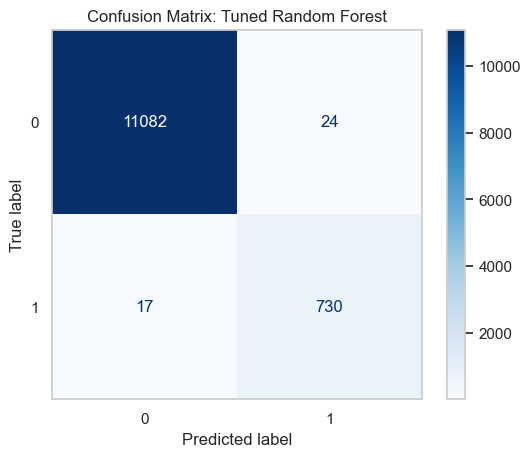

In [33]:
cm = confusion_matrix(y_test, final_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Tuned Random Forest")
plt.grid(False)
plt.show()

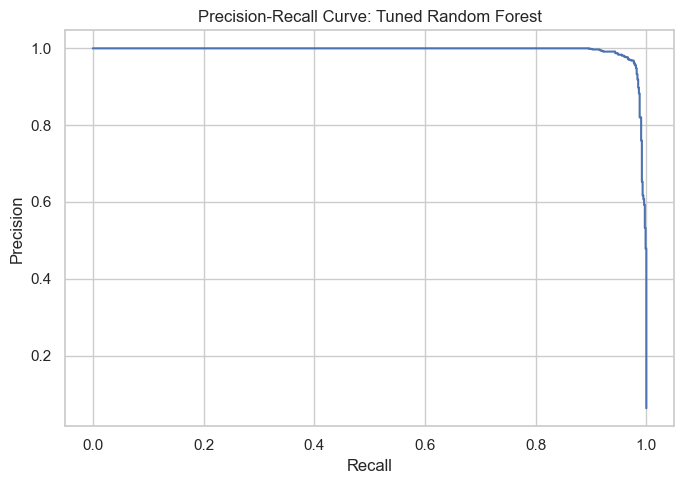

In [34]:
precision_vals_final, recall_vals_final, _ = precision_recall_curve(y_test, final_probabilities)

plt.figure(figsize=(7, 5))
plt.plot(recall_vals_final, precision_vals_final)
plt.title("Precision-Recall Curve: Tuned Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()

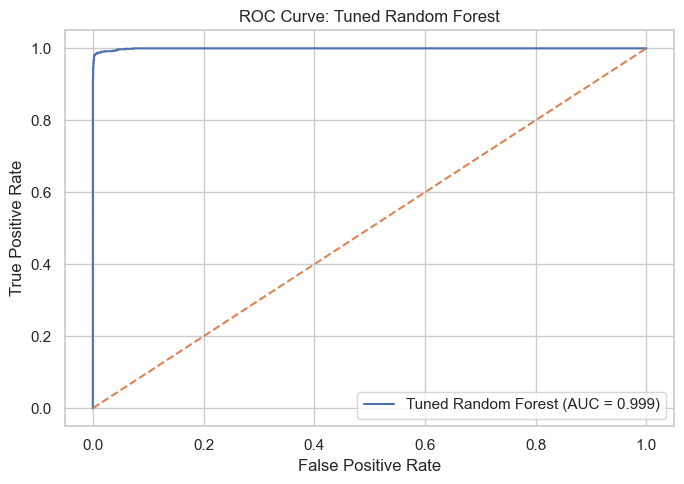

In [35]:
fpr_final, tpr_final, _ = roc_curve(y_test, final_probabilities)

plt.figure(figsize=(7, 5))
plt.plot(fpr_final, tpr_final, label=f"Tuned Random Forest (AUC = {final_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve: Tuned Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Feature Importance

Feature importance helps translate the model into practical business language by showing which engineered signals contribute most to the final matching decision.


In [36]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
importances = final_model.named_steps["model"].feature_importances_

feature_importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .head(15)
)

feature_importance_df

,Feature,Importance
1,num__name_partial_similarity,0.174186
12,num__street_len_diff,0.139551
0,num__name_similarity,0.115144
2,num__street_similarity,0.096545
11,num__name_len_diff,0.090702
7,num__same_city,0.071500
3,num__city_similarity,0.063395
9,num__same_postal,0.059268
6,num__industry_similarity,0.055472
4,num__state_similarity,0.042941


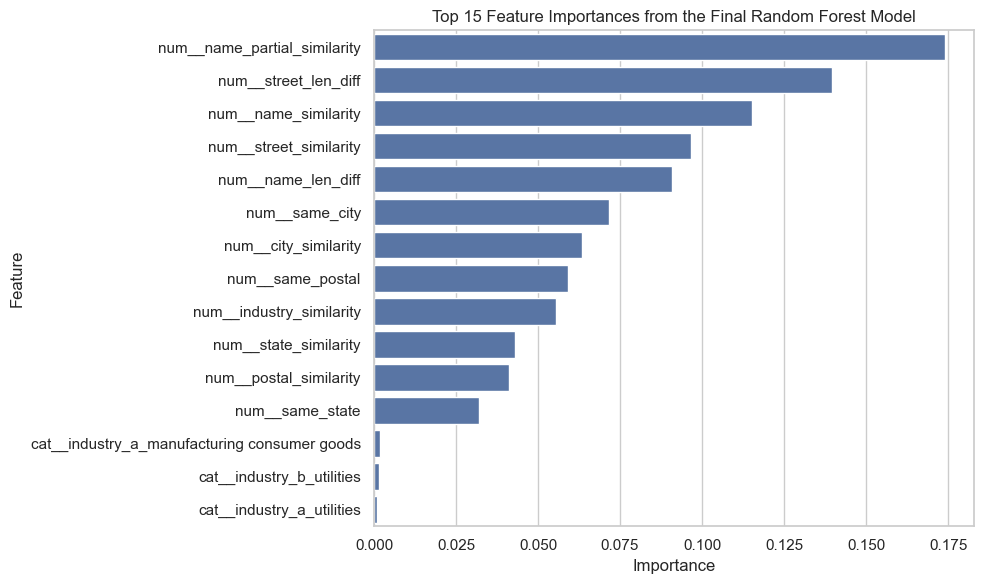

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Top 15 Feature Importances from the Final Random Forest Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 18. Final Business Interpretation

From a business perspective, **incorrectly merging two different companies is more harmful than missing a few duplicate pairs**. That is why precision remains an important evaluation metric in this project.

The most practical use of this solution is to:
- flag likely duplicate account pairs
- route them for human review
- improve CRM hygiene over time
- support more reliable reporting and customer rollups

The modeling results also show that:
- company-name similarity is the strongest signal
- address-related features add confidence
- ensemble models such as Random Forest are well suited for non-linear matching problems


## 19. Final Findings

1. The account dataset contains real duplication and hierarchy-quality issues.  
2. Pairwise similarity features turn raw CRM records into a useful supervised-learning problem.  
3. The derived pair dataset is strongly imbalanced, so precision, recall, F1-score, and PR analysis are more informative than accuracy alone.  
4. Logistic Regression is a strong interpretable baseline.  
5. Random Forest performs best overall and is the strongest candidate for a production-oriented next step.  
6. This workflow demonstrates how machine learning can support enterprise account matching even when fully curated labels are not initially available.


## 20. Recommendations and Next Steps

### Immediate recommendations
- Use the final model to flag likely duplicate account pairs for review  
- Apply a conservative threshold to reduce false merges  
- Validate a sample of model predictions with business stakeholders  

### Future improvements
- Collect curated match labels from business reviewers  
- Add richer features such as website domain or external company identifiers  
- Improve candidate-pair blocking logic  
- Explore boosted tree models for further performance gains  
- Integrate the workflow into CRM or master-data management processes
